<a href="https://colab.research.google.com/github/ayushpandey9092/face-liveness-detector/blob/main/FacelivenessLBH_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
print("Hello! My liveness detector project has started.")

Hello! My liveness detector project has started.


In [3]:
!pip install opencv-python-headless scikit-image scikit-learn matplotlib numpy

In [4]:
import cv2                          # opencv - for reading images
import numpy as np                  # numpy - for number grids
import matplotlib.pyplot as plt     # matplotlib - for showing images
from skimage import feature         # scikit-image - for LBP features
from sklearn.svm import SVC         # scikit-learn - our classifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


Image is just a grid of numbers:
[[ 10  20  30  20  10]
 [ 20  80 120  80  20]
 [ 30 120 255 120  30]
 [ 20  80 120  80  20]
 [ 10  20  30  20  10]]

Shape (rows, columns): (5, 5)


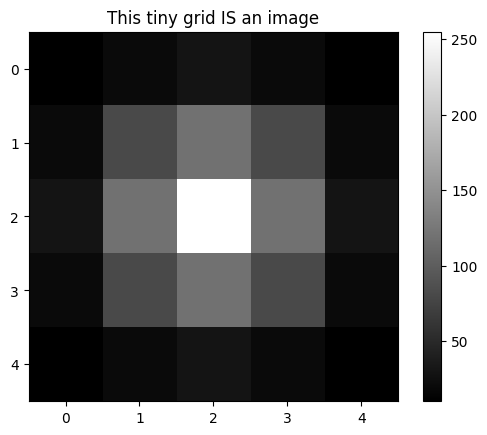

In [5]:
# Create a tiny 5x5 fake image (just numbers)
fake_image = np.array([
    [10,  20,  30,  20,  10],
    [20,  80, 120,  80,  20],
    [30, 120, 255, 120,  30],
    [20,  80, 120,  80,  20],
    [10,  20,  30,  20,  10]
], dtype=np.uint8)

print("Image is just a grid of numbers:")
print(fake_image)
print()
print("Shape (rows, columns):", fake_image.shape)

# Show it as an actual image
plt.imshow(fake_image, cmap='gray')
plt.title("This tiny grid IS an image")
plt.colorbar()
plt.show()

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
import zipfile

# Unzip the dataset from your Drive into Colab
with zipfile.ZipFile('/content/drive/MyDrive/FaceLiveness DATA.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/face_liveness')

print("Done unzipping!")

Done unzipping!


In [8]:
import os

for item in os.listdir('/content/face_liveness'):
    print(item)

raw


In [9]:
import os

for item in os.listdir('/content/face_liveness/raw'):
    print(item)



imposter_train_raw.txt
client_train_raw.txt
ClientRaw
ImposterRaw
client_test_raw.txt
imposter_test_raw.txt


In [10]:
import os

real_folder = '/content/face_liveness/raw/ClientRaw'
fake_folder = '/content/face_liveness/raw/ImposterRaw'

real_images = os.listdir(real_folder)
fake_images = os.listdir(fake_folder)

print("Total real face images:", len(real_images))
print("Total fake face images:", len(fake_images))
import os

# Look inside ClientRaw
print("Inside ClientRaw:")
for item in os.listdir('/content/face_liveness/raw/ClientRaw'):
    print(" ", item)

Total real face images: 15
Total fake face images: 15
Inside ClientRaw:
  0009
  0012
  0006
  0008
  0004
  0003
  0002
  0015
  0014
  0001
  0013
  0011
  0010
  0007
  0005


In [11]:
import os

real_folder = '/content/face_liveness/raw/ClientRaw'
fake_folder = '/content/face_liveness/raw/ImposterRaw'

# Count all images inside all subfolders
real_all = []
for subfolder in os.listdir(real_folder):
    subfolder_path = os.path.join(real_folder, subfolder)
    for img in os.listdir(subfolder_path):
        real_all.append(os.path.join(subfolder_path, img))

fake_all = []
for subfolder in os.listdir(fake_folder):
    subfolder_path = os.path.join(fake_folder, subfolder)
    for img in os.listdir(subfolder_path):
        fake_all.append(os.path.join(subfolder_path, img))

print("Total real images found:", len(real_all))
print("Total fake images found:", len(fake_all))
print()
print("Example real image path:", real_all[0])
print("Example fake image path:", fake_all[0])

Total real images found: 5120
Total fake images found: 7523

Example real image path: /content/face_liveness/raw/ClientRaw/0009/0009_01_00_01_442.jpg
Example fake image path: /content/face_liveness/raw/ImposterRaw/0009/0009_01_03_03_65.jpg


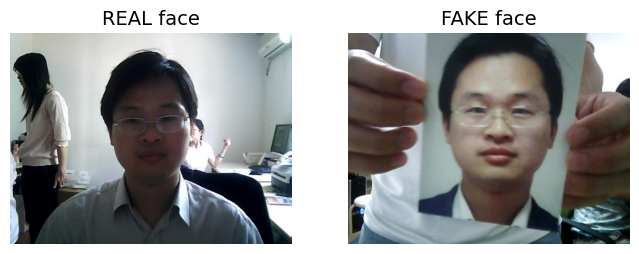

In [12]:
import cv2
import matplotlib.pyplot as plt

# Load one real and one fake image
real_img = cv2.imread(real_all[0])
fake_img = cv2.imread(fake_all[0])

# Convert color (OpenCV loads as BGR, we need RGB for display)
real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)
fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)

# Show both side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(real_img)
axes[0].set_title("REAL face", fontsize=14)
axes[0].axis('off')

axes[1].imshow(fake_img)
axes[1].set_title("FAKE face", fontsize=14)
axes[1].axis('off')

plt.show()

In [13]:
import cv2
import numpy as np
from skimage import feature
import matplotlib.pyplot as plt

def extract_lbp(image_path):
    # Step 1 - Read the image
    img = cv2.imread(image_path)

    # Step 2 - Convert to grayscale (LBP works on gray images)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 3 - Resize to same size (so all feature lists are same length)
    gray = cv2.resize(gray, (100, 100))

    # Step 4 - Extract LBP features
    lbp = feature.local_binary_pattern(gray, P=8, R=1, method='uniform')

    # Step 5 - Convert LBP image into a histogram (list of numbers)
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))

    # Step 6 - Normalize so all values are between 0 and 1
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-6)

    return hist

# Test it on one real image
features = extract_lbp(real_all[0])

print("LBP features for one real face:")
print(features)
print()
print("Total numbers in feature list:", len(features))

LBP features for one real face:
[0.04   0.0616 0.0421 0.1103 0.2472 0.1857 0.0658 0.0663 0.0873 0.0937]

Total numbers in feature list: 10


In [14]:
import numpy as np

X = []  # will store features for every image
y = []  # will store label - 1 for real, 0 for fake

print("Extracting features from real images...")
for i, path in enumerate(real_all):
    try:
        hist = extract_lbp(path)
        X.append(hist)
        y.append(1)          # 1 means REAL
    except:
        pass                 # skip broken images
    if i % 500 == 0:
        print(f"  Processed {i} / {len(real_all)} real images")

print("Done with real images!")
print()

print("Extracting features from fake images...")
for i, path in enumerate(fake_all):
    try:
        hist = extract_lbp(path)
        X.append(hist)
        y.append(0)          # 0 means FAKE
    except:
        pass                 # skip broken images
    if i % 500 == 0:
        print(f"  Processed {i} / {len(fake_all)} fake images")

print("Done with fake images!")
print()

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("Final shape of X (features):", X.shape)
print("Final shape of y (labels)  :", y.shape)
print()
print("Total real images processed:", sum(y == 1))
print("Total fake images processed:", sum(y == 0))

Extracting features from real images...
  Processed 0 / 5120 real images
  Processed 500 / 5120 real images
  Processed 1000 / 5120 real images
  Processed 1500 / 5120 real images
  Processed 2000 / 5120 real images
  Processed 2500 / 5120 real images
  Processed 3000 / 5120 real images
  Processed 3500 / 5120 real images
  Processed 4000 / 5120 real images
  Processed 4500 / 5120 real images
  Processed 5000 / 5120 real images
Done with real images!

Extracting features from fake images...
  Processed 0 / 7523 fake images
  Processed 500 / 7523 fake images
  Processed 1000 / 7523 fake images
  Processed 1500 / 7523 fake images
  Processed 2000 / 7523 fake images
  Processed 2500 / 7523 fake images
  Processed 3000 / 7523 fake images
  Processed 3500 / 7523 fake images
  Processed 4000 / 7523 fake images
  Processed 4500 / 7523 fake images
  Processed 5000 / 7523 fake images
  Processed 5500 / 7523 fake images
  Processed 6000 / 7523 fake images
  Processed 6500 / 7523 fake images
  Pr

In [15]:
from sklearn.model_selection import train_test_split

# Split data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to testing
    random_state=42     # makes sure we get same split every time
)

print("Training images:", len(X_train))
print("Testing images :", len(X_test))
print()
print("Example - first training sample (10 numbers):", X_train[0])
print("Example - its label (1=real, 0=fake)        :", y_train[0])

Training images: 10091
Testing images : 2523

Example - first training sample (10 numbers): [0.0411 0.0657 0.0497 0.1338 0.2332 0.1602 0.062  0.0686 0.0829 0.1028]
Example - its label (1=real, 0=fake)        : 0


In [16]:
from sklearn.svm import SVC

# Create the classifier
model = SVC(kernel='rbf', probability=True)

# Train it - this is where the learning happens
print("Training the model... please wait...")
model.fit(X_train, y_train)

print("Training done!")

Training the model... please wait...
Training done!


In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Test the model on images it has never seen before
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")
print()
print("Detailed Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

Accuracy: 90.05 %

Detailed Report:
              precision    recall  f1-score   support

        Fake       0.87      0.97      0.92      1478
        Real       0.95      0.80      0.87      1045

    accuracy                           0.90      2523
   macro avg       0.91      0.89      0.89      2523
weighted avg       0.91      0.90      0.90      2523



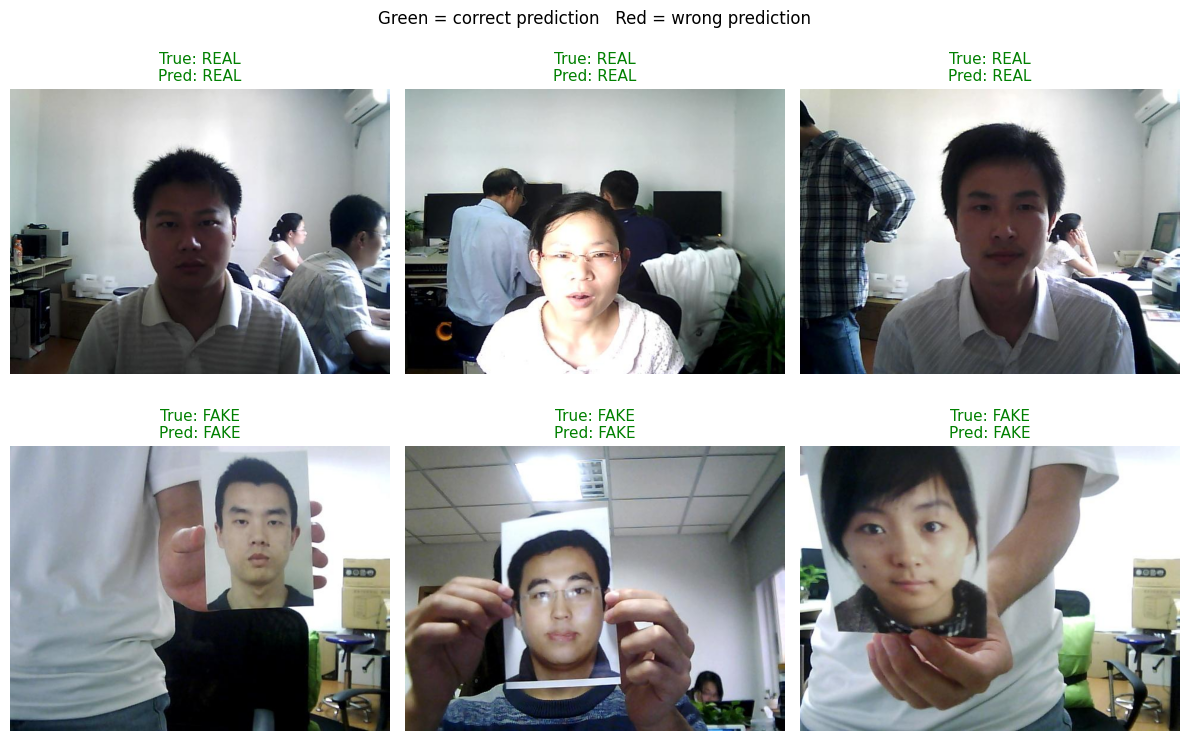

In [18]:
import random

# Pick 6 random images - mix of real and fake
samples = [
    (random.choice(real_all), 'REAL'),
    (random.choice(real_all), 'REAL'),
    (random.choice(real_all), 'REAL'),
    (random.choice(fake_all), 'FAKE'),
    (random.choice(fake_all), 'FAKE'),
    (random.choice(fake_all), 'FAKE'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, (path, true_label) in enumerate(samples):
    features = extract_lbp(path)
    prediction = model.predict([features])[0]
    pred_label = 'REAL' if prediction == 1 else 'FAKE'

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].axis('off')

    # Green title if correct, red if wrong
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        fontsize=11,
        color=color
    )

plt.suptitle("Green = correct prediction   Red = wrong prediction", fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
import pickle

# Save the model to a file
with open('liveness_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [20]:
# Load it back and test
with open('liveness_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Quick test
test_features = extract_lbp(real_all[0])
prediction = loaded_model.predict([test_features])[0]
print("Model loaded successfully!")
print("Test prediction:", "REAL" if prediction == 1 else "FAKE")

Model loaded successfully!
Test prediction: REAL


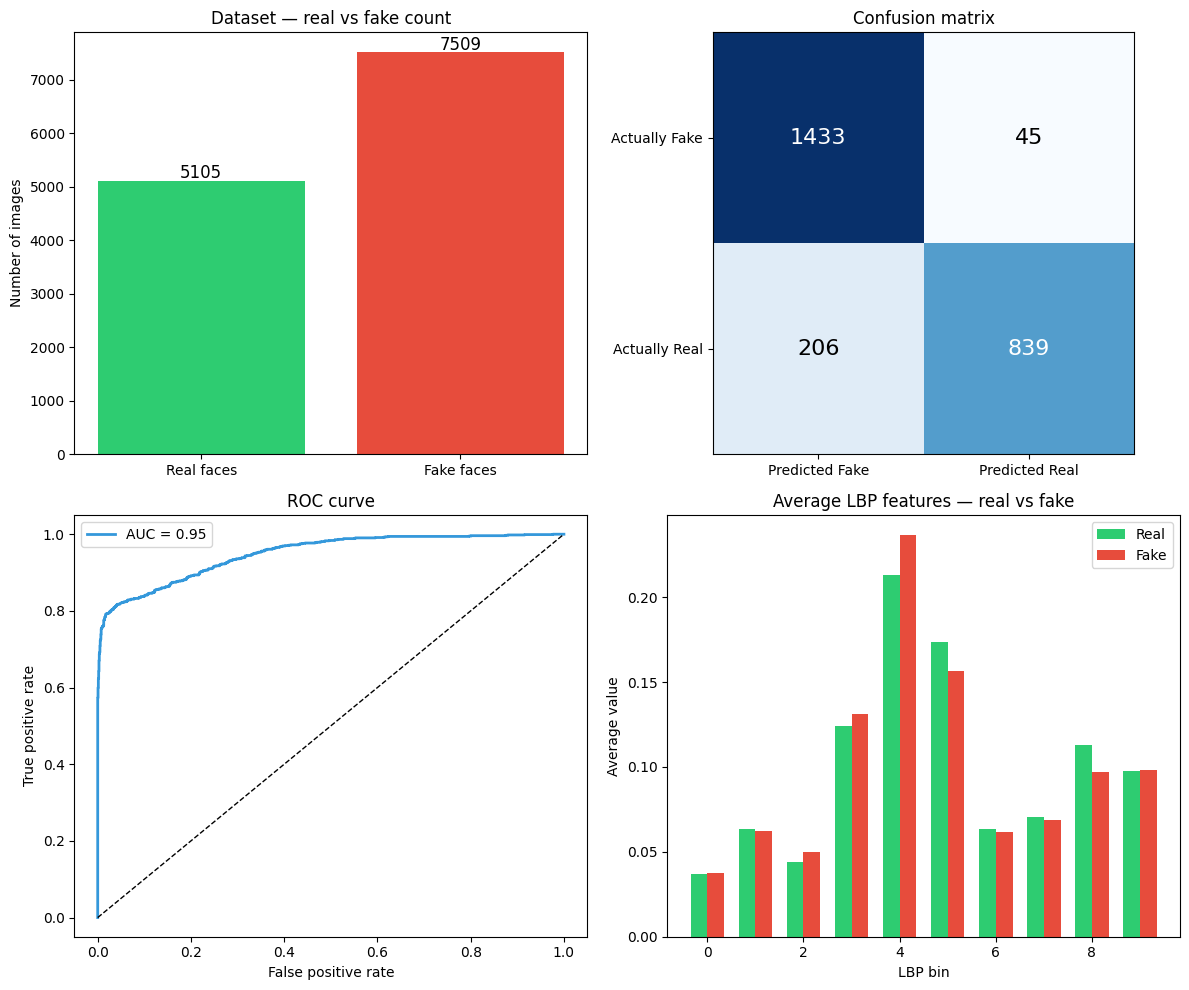

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Graph 1 - How many real vs fake images we have ──
axes[0,0].bar(['Real faces', 'Fake faces'],
              [sum(y==1), sum(y==0)],
              color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Dataset — real vs fake count')
axes[0,0].set_ylabel('Number of images')
for i, v in enumerate([sum(y==1), sum(y==0)]):
    axes[0,0].text(i, v + 50, str(v), ha='center', fontsize=12)

# ── Graph 2 - Confusion matrix ──
cm = confusion_matrix(y_test, y_pred)
im = axes[0,1].imshow(cm, cmap='Blues')
axes[0,1].set_title('Confusion matrix')
axes[0,1].set_xticks([0,1])
axes[0,1].set_yticks([0,1])
axes[0,1].set_xticklabels(['Predicted Fake', 'Predicted Real'])
axes[0,1].set_yticklabels(['Actually Fake', 'Actually Real'])
for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, cm[i,j], ha='center',
                       va='center', fontsize=16,
                       color='white' if cm[i,j] > 500 else 'black')

# ── Graph 3 - ROC Curve ──
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1,0].plot(fpr, tpr, color='#3498db', linewidth=2,
               label=f'AUC = {roc_auc:.2f}')
axes[1,0].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1,0].set_title('ROC curve')
axes[1,0].set_xlabel('False positive rate')
axes[1,0].set_ylabel('True positive rate')
axes[1,0].legend()

# ── Graph 4 - LBP feature comparison real vs fake ──
real_features = X[y==1].mean(axis=0)
fake_features = X[y==0].mean(axis=0)
x = np.arange(10)
width = 0.35
axes[1,1].bar(x - width/2, real_features, width,
              label='Real', color='#2ecc71')
axes[1,1].bar(x + width/2, fake_features, width,
              label='Fake', color='#e74c3c')
axes[1,1].set_title('Average LBP features — real vs fake')
axes[1,1].set_xlabel('LBP bin')
axes[1,1].set_ylabel('Average value')
axes[1,1].legend()

plt.tight_layout()
plt.show()

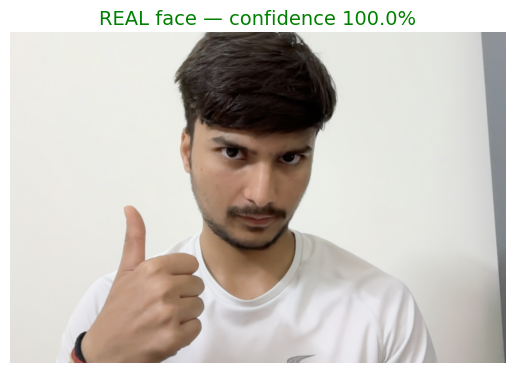

REAL face — confidence 100.0%


In [24]:
import cv2
import matplotlib.pyplot as plt

# Change this to your actual filename
my_image_path = '/content/your_photo.jpeg'

# Extract features
my_features = extract_lbp(my_image_path)

# Predict
prediction = loaded_model.predict([my_features])[0]
confidence = loaded_model.predict_proba([my_features])[0]

# Show result
img = cv2.imread(my_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

if prediction == 1:
    result = f"REAL face — confidence {round(confidence[1]*100, 1)}%"
    color = 'green'
else:
    result = f"FAKE face — confidence {round(confidence[0]*100, 1)}%"
    color = 'red'

plt.title(result, fontsize=14, color=color)
plt.show()
print(result)

In [25]:
from google.colab import files
files.download('liveness_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>